# Cross-Market Promotion Effect Audit

**Business question:** How much of Market A's March 2026 sales can reasonably be associated with a price promotion?

The workflow separates the observed sales change from the estimated promotion effect, builds a comparison-market counterfactual, and documents the assumptions that limit causal interpretation.

> **Data note:** Market labels, product context, and numerical values are fictionalized for this public portfolio case study.


## Stage 1 — Analytical framing

The observed calculation is:

$$
\$10.7M - \$9.1M = \$1.6M
$$

This describes the March 2025-to-2026 change, but it does not identify what would have happened without the promotion.

$$
	ext{Promotion effect} = 	ext{Observed sales} - 	ext{Counterfactual sales without promotion}
$$

Because the counterfactual is unobserved, Market B is used as an imperfect comparison and Market A's own history provides a sensitivity check.


In [1]:
# Core libraries only: the dataset is small and does not require a complex modelling stack.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    # Keeps the notebook executable in a minimal Python environment.
    display = print

pd.options.display.float_format = "{:,.3f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## Stage 2 — Data reconstruction and validation

### Assumptions made when entering the supplied figures

- `sales_usd_m` means reported sales revenue in millions of US dollars.
- All figures use the same revenue definition.
- No missing values are inferred or filled; only fictionalized values in this case study are used.

In [2]:
# Fictionalized annual March sales supplied within this case study.
market_a = pd.DataFrame({
    "year": [2021, 2022, 2023, 2024, 2025, 2026],
    "sales_usd_m": [9.4, 9.8, 9.6, 10.2, 9.1, 10.7],
    "promotion": [False, False, False, False, False, True],
})

market_b = pd.DataFrame({
    "year": [2024, 2025, 2026],
    "sales_usd_m": [7.1, 7.0, 6.9],
    "promotion": [False, False, False],
})

assert market_a["year"].is_unique and market_b["year"].is_unique
assert not market_a.isna().any().any() and not market_b.isna().any().any()
assert (market_a["sales_usd_m"] >= 0).all() and (market_b["sales_usd_m"] >= 0).all()
assert market_a.loc[market_a["year"].eq(2026), "promotion"].all()
assert not market_b["promotion"].any()

print("Market A observations:", len(market_a))
display(market_a)
print()
print("Market B observations:", len(market_b))
display(market_b)


Market A observations: 6
   year  sales_usd_m  promotion
0  2021        9.400      False
1  2022        9.800      False
2  2023        9.600      False
3  2024       10.200      False
4  2025        9.100      False
5  2026       10.700       True

Market B observations: 3
   year  sales_usd_m  promotion
0  2024        7.100      False
1  2025        7.000      False
2  2026        6.900      False


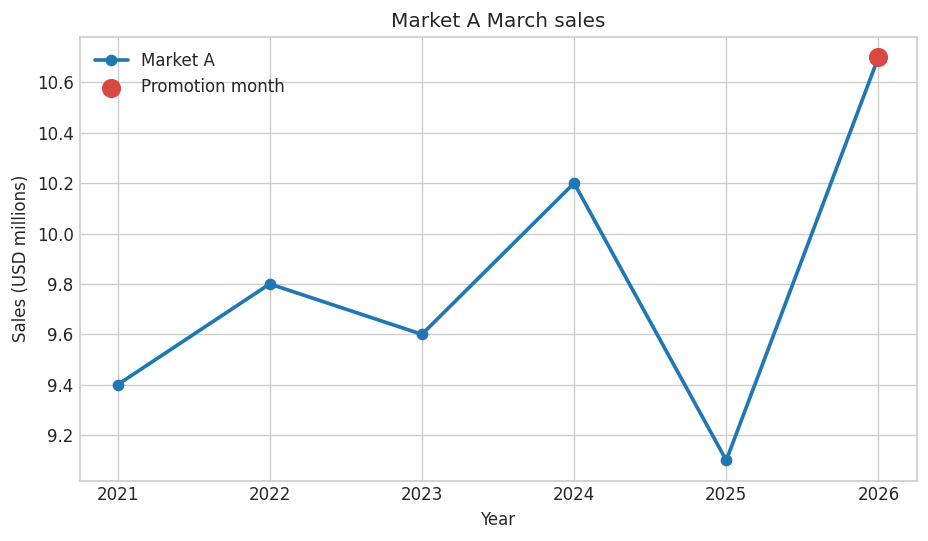

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(market_a["year"], market_a["sales_usd_m"], marker="o", linewidth=2.2, label="Market A")
ax.scatter([2026], [10.7], s=110, color="#D94841", zorder=3, label="Promotion month")
ax.set(title="Market A March sales", xlabel="Year", ylabel="Sales (USD millions)")
ax.legend()
plt.show()


### Initial observation

Market A's March sales ranged from `$9.4M` to `$10.2M` between 2021 and 2024, then fell to `$9.1M` in 2025. A direct comparison with 2025 may therefore overstate the promotion effect because it uses an unusually weak baseline.


## Stage 3 — The colleague's year-over-year calculation

This stage checks the headline statement before attempting causal attribution.

In [4]:
market_a_2025 = market_a.loc[market_a["year"].eq(2025), "sales_usd_m"].iloc[0]
market_a_2026 = market_a.loc[market_a["year"].eq(2026), "sales_usd_m"].iloc[0]

observed_change = market_a_2026 - market_a_2025
observed_growth_pct = observed_change / market_a_2025

print(f"Observed sales change: ${observed_change:.1f}M")
print(f"Observed year-over-year growth: {observed_growth_pct:.1%}")

Observed sales change: $1.6M
Observed year-over-year growth: 17.6%


### Conclusion from Stage 3

The `$1.6M` statement is arithmetically correct as an **observed year-over-year change**. It becomes a promotion-effect estimate only under the strong assumption that Market A would otherwise have repeated its weak March 2025 result.


## Stage 4 — Primary no-promotion counterfactual

### Methodology

1. Measure Market B's March 2025-to-2026 change, where no promotion ran.
2. Treat that movement as an estimate of shared market conditions.
3. Apply the percentage change to Market A's March 2025 sales.
4. Subtract the counterfactual from Market A's observed March 2026 sales.

A proportional adjustment is the primary method because the markets have different revenue sizes. An additive difference-in-differences calculation is retained as a simple robustness check.

### Key assumption

Without the promotion, both markets would have experienced a similar proportional change. The limited pre-period data cannot establish this assumption confidently.


In [5]:
market_b_2025 = market_b.loc[market_b["year"].eq(2025), "sales_usd_m"].iloc[0]
market_b_2026 = market_b.loc[market_b["year"].eq(2026), "sales_usd_m"].iloc[0]

# Multiplicative comparison-market adjustment (primary working method).
market_b_growth_factor = market_b_2026 / market_b_2025
market_b_growth_pct = market_b_growth_factor - 1
counterfactual_control_adjusted = market_a_2025 * market_b_growth_factor
effect_control_adjusted = market_a_2026 - counterfactual_control_adjusted
lift_vs_counterfactual = effect_control_adjusted / counterfactual_control_adjusted

# Additive difference-in-differences check.
market_b_absolute_change = market_b_2026 - market_b_2025
counterfactual_additive = market_a_2025 + market_b_absolute_change
effect_additive = market_a_2026 - counterfactual_additive

print(f"Market B 2025→2026 change: {market_b_growth_pct:.1%} (${market_b_absolute_change:.1f}M)")
print(f"Primary counterfactual for Market A: ${counterfactual_control_adjusted:.2f}M")
print(f"Primary estimated incremental sales: ${effect_control_adjusted:.2f}M")
print(f"Estimated lift versus counterfactual: {lift_vs_counterfactual:.1%}")
print(f"Additive DiD robustness estimate: ${effect_additive:.2f}M")

Market B 2025→2026 change: -1.4% ($-0.1M)
Primary counterfactual for Market A: $8.97M
Primary estimated incremental sales: $1.73M
Estimated lift versus counterfactual: 19.3%
Additive DiD robustness estimate: $1.70M


### Conclusion from Stage 4

Market B declined by about `1.4%`. Applying that movement to Market A gives a no-promotion estimate of approximately `$9.0M` and an incremental-sales estimate of approximately `$1.7M`.

The additive calculation is very similar, but agreement between two simple adjustments does not prove that Market B is a fully comparable control.


## Stage 5 — Sense-checking the estimate

Market B is useful because it had no promotion, but it is not a perfect control. Between March 2024 and March 2025, Market A declined by `10.8%`, while Market B declined by `1.4%`, showing that the markets do not always move in parallel.

I therefore use two reference points:

1. Market B's 2025–2026 movement implies approximately `$1.7M` of incremental sales.
2. Market A's 2021–2025 historical March average implies approximately `$1.1M`.

The practical sensitivity range is therefore **$1.1M–$1.7M**. It is not a formal confidence interval.


In [6]:
# Comparison-market estimate
market_b_change_pct = 6.9 / 7.0 - 1
market_a_counterfactual_market_b = 9.1 * (1 + market_b_change_pct)
promotion_effect_market_b = 10.7 - market_a_counterfactual_market_b

# Market A historical-average sense check
market_a_historical_average = np.mean([9.4, 9.8, 9.6, 10.2, 9.1])
promotion_effect_history = 10.7 - market_a_historical_average

print(f"Market B-adjusted no-promotion estimate: ${market_a_counterfactual_market_b:.1f}M")
print(f"Market B-adjusted promotion effect: ${promotion_effect_market_b:.1f}M")
print(f"Historical-average promotion effect: ${promotion_effect_history:.1f}M")
print("Sensitivity range: $1.1M–$1.7M")


Market B-adjusted no-promotion estimate: $9.0M
Market B-adjusted promotion effect: $1.7M
Historical-average promotion effect: $1.1M
Sensitivity range: $1.1M–$1.7M


### Conclusion from Stage 5

The comparison-market method implies approximately `$1.7M` of incremental sales, while Market A's historical average implies approximately `$1.1M`. I would therefore report a sensitivity range of `$1.1M–$1.7M`, with `$9.0M` as the primary counterfactual.

The observed `$1.6M` increase lies inside that range, but the available evidence does not justify presenting it as proven causal impact.


## Stage 6 — Other factors influencing the result

| Factor | Treatment in this analysis |
|---|---|
| Shared commercial conditions | Market B provides an imperfect proxy. |
| Weak Market A baseline | Market A's longer March history is used as a sensitivity check. |
| Market differences | A range is reported instead of one precise causal value. |
| Other campaigns or availability | These are not observed and remain limitations. |
| Timing and profitability | Demand may have shifted between months; margin and promotion-cost data are unavailable. |


## Stage 7 — Key assumptions and limitations

1. Shared conditions affected Market A and Market B in reasonably comparable ways.
2. No unobserved Market A-specific campaign or disruption explains the change.
3. Sales are measured consistently across markets and years.
4. The promotion generated new demand rather than only shifting purchases between months.

The analysis is a transparent sensitivity exercise, not a causal experiment. More pre-period observations, post-period months, unit economics, and an independently justified control market would strengthen the conclusion.


## Stage 8 — Final conclusion

The primary comparison-market calculation estimates that Market A would have generated approximately **$9.0M** without the promotion, implying about **$1.7M** in incremental March sales.

Because the markets did not move in parallel during the available pre-period, Market A's historical average provides a second baseline. Together, the methods support a cautious range of **$1.1M–$1.7M**.

The observed **$1.6M** year-over-year increase is plausible as an effect estimate, but it is not causal proof. These figures describe additional sales, not profit or ROI.


## Five-line business summary

1. Market A's March sales increased by `$1.6M` year over year, but this is not automatically the promotion effect.  
2. Market B's no-promotion movement implies a Market A counterfactual of approximately `$9.0M`.  
3. This produces a primary incremental-sales estimate of approximately `$1.7M`.  
4. Market A's own history supports a broader sensitivity range of `$1.1M–$1.7M`.  
5. A stronger decision would require more history, unit economics, timing data, and a better-validated comparison market.
